# Import data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kruskal, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
import scikit_posthocs as sp

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

In [3]:
FILE_PATH = "test_results.csv"  # Change this to your file path

df = pd.read_csv(FILE_PATH)
print(df['model_name'].unique())

df.head()

['best_model_marouane' 'best_model_sohaib']


,model_name,episode,survival_time,zombies_killed,wave_achieved
0,best_model_marouane,1,3573,75,8
1,best_model_marouane,2,3958,76,8
2,best_model_marouane,3,642,11,2
3,best_model_marouane,4,4379,100,11
4,best_model_marouane,5,2765,52,6


# descriptive statistics

In [4]:
import pandas as pd

metrics = ['survival_time', 'zombies_killed', 'wave_achieved']

# Containers for each metric
survival_stats = []
zombies_stats = []
wave_stats = []

for model in sorted(df['model_name'].unique()):
    model_data = df[df['model_name'] == model]
    
    for metric in metrics:
        data = model_data[metric]
        
        stats_dict = {
            'Model': model,
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75),
            'IQR': data.quantile(0.75) - data.quantile(0.25)
        }
        
        if metric == 'survival_time':
            survival_stats.append(stats_dict)
        elif metric == 'zombies_killed':
            zombies_stats.append(stats_dict)
        elif metric == 'wave_achieved':
            wave_stats.append(stats_dict)

# Create DataFrames
df_survival_time = pd.DataFrame(survival_stats)
df_zombies_killed = pd.DataFrame(zombies_stats)
df_wave_achieved = pd.DataFrame(wave_stats)


In [5]:
print("Survival Time Summary:")
df_survival_time

Survival Time Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model_marouane,3298.56,3417.0,1171.775329,159,5898,2762.50,3989.75,1227.25
1,best_model_sohaib,2902.53,3213.5,1571.443076,243,5967,1695.75,4256.75,2561.00


In [6]:
print("Zombies Killed Summary:")
df_zombies_killed

Zombies Killed Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model_marouane,68.10,67.5,28.983625,2,156,53.0,85.75,32.75
1,best_model_sohaib,60.03,63.0,39.903281,1,151,28.5,93.00,64.50


In [7]:
print("Wave Achieved Summary:")
df_wave_achieved

Wave Achieved Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model_marouane,7.26,7.0,2.959730,1,16,6.0,9.0,3.0
1,best_model_sohaib,6.47,6.5,4.058798,1,16,3.0,10.0,7.0


# Fiding the best parameters to test on

## Correlation test (pearson & spearman)

In [8]:
metrics = ['survival_time', 'zombies_killed', 'wave_achieved']
correlation_results = []

for i, metric1 in enumerate(metrics):
    for metric2 in metrics[i+1:]:
        corr, p_value = pearsonr(df[metric1], df[metric2])
        correlation_results.append({
            'Metric 1': metric1,
            'Metric 2': metric2,
            'Correlation Type': 'Pearson',
            'Correlation': corr,
            'p_value': p_value
        })

for i, metric1 in enumerate(metrics):
    for metric2 in metrics[i+1:]:
        corr, p_value = spearmanr(df[metric1], df[metric2])
        correlation_results.append({
            'Metric 1': metric1,
            'Metric 2': metric2,
            'Correlation Type': 'Spearman',
            'Correlation': corr,
            'p_value': p_value
        })
        

corr_df = pd.DataFrame(correlation_results)
corr_df

,Metric 1,Metric 2,Correlation Type,Correlation,p_value
0,survival_time,zombies_killed,Pearson,0.970707,1.392191e-124
1,survival_time,wave_achieved,Pearson,0.963296,4.804148e-115
2,zombies_killed,wave_achieved,Pearson,0.992922,3.530299e-185
3,survival_time,zombies_killed,Spearman,0.983942,3.798839e-150
4,survival_time,wave_achieved,Spearman,0.973129,3.047176e-128
5,zombies_killed,wave_achieved,Spearman,0.989697,4.190907e-169


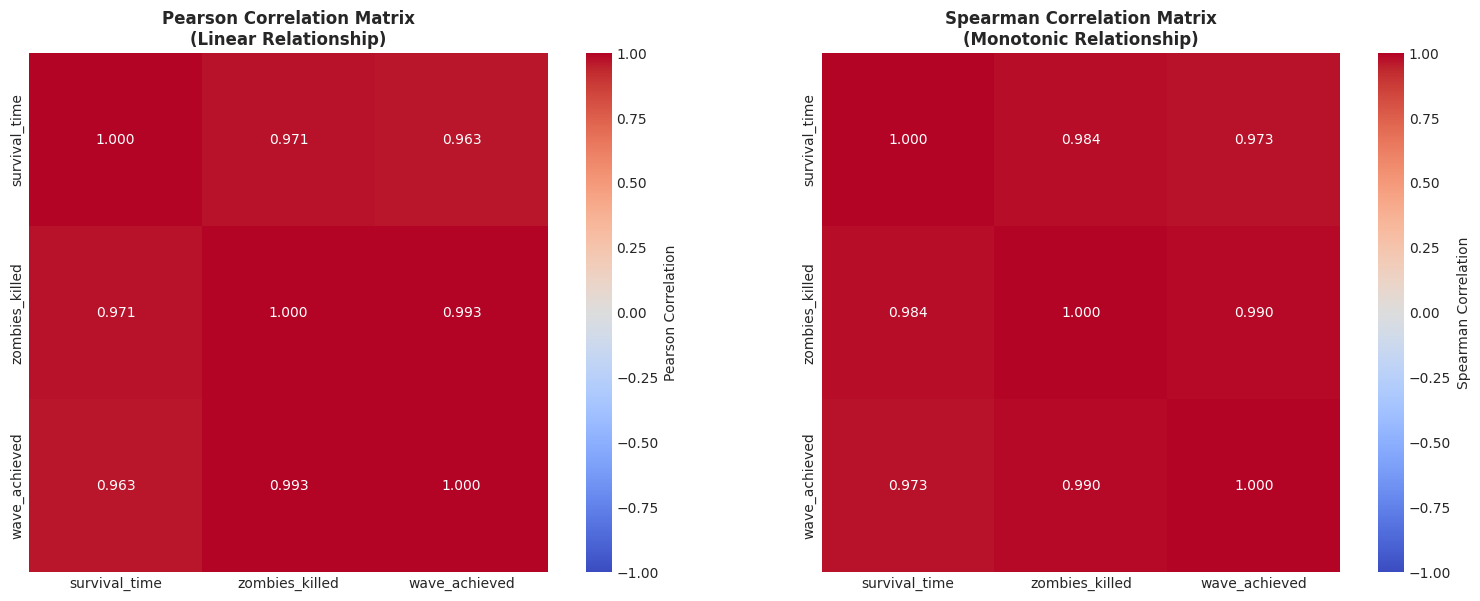

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson correlation heatmap
corr_matrix_pearson = df[metrics].corr(method='pearson')
sns.heatmap(corr_matrix_pearson, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True,
            cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title('Pearson Correlation Matrix\n(Linear Relationship)', 
                  fontsize=12, fontweight='bold')

# Spearman correlation heatmap
corr_matrix_spearman = df[metrics].corr(method='spearman')
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True,
            cbar_kws={'label': 'Spearman Correlation'})
axes[1].set_title('Spearman Correlation Matrix\n(Monotonic Relationship)', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

we will do test on the survival_time

# STatical test

## Normality test (shapiro)

In [10]:
METRIC = 'survival_time'

In [11]:
print("Shapiro-Wilk")

normality_results = []
all_normal = True

for model in sorted(df['model_name'].unique()):
    model_data = df[df['model_name'] == model][METRIC].values
    stat, p_value = shapiro(model_data)
    is_normal = p_value > 0.05
    
    if not is_normal:
        all_normal = False
    
    normality_results.append({
        'Model': model,
        'Statistic': stat,
        'p_value': p_value,
        'Normal?': 'Yes' if is_normal else 'No'
    })
    

normality_df = pd.DataFrame(normality_results)
normality_df


Shapiro-Wilk


,Model,Statistic,p_value,Normal?
0,best_model_marouane,0.963554,0.007265,No
1,best_model_sohaib,0.939802,0.000188,No


At least one group is not normal -> Will use Kruskal-Wallis (non-parametric)

## Kruskal-Wallis Test (Non-Parametric Alternative to ANOVA)
Since data is not normally distributed, we use Kruskal-Wallis test to determine if there are significant differences between models.

In [12]:
print("\n" + "="*80)
print("KRUSKAL-WALLIS TEST (Non-Parametric)")
print("="*80)
print("H0: All groups have the same distribution (no significant difference)")
print("H1: At least one group is different")
print("If p < 0.05: Reject H0 → Significant difference exists between groups")
print("="*80)

# Prepare data for each model
groups = []
model_names = sorted(df['model_name'].unique())

for model in model_names:
    groups.append(df[df['model_name'] == model][METRIC].values)

# Perform Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print(f"\nTest Statistic (H): {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {len(model_names) - 1}")


KRUSKAL-WALLIS TEST (Non-Parametric)
H0: All groups have the same distribution (no significant difference)
H1: At least one group is different
If p < 0.05: Reject H0 → Significant difference exists between groups

Test Statistic (H): 2.0536
p-value: 0.151844
Degrees of freedom: 1


In [13]:
# Interpret the result
if p_value < 0.05:
    print(f"RESULT: p-value = {p_value:.6f} < 0.05 → Significant difference exists between models!")
else:
    print(f"RESULT: p-value = {p_value:.6f} >= 0.05 → No significant difference between models")

RESULT: p-value = 0.151844 >= 0.05 → No significant difference between models


In [14]:
print("Survival Time Summary:")
df_survival_time

Survival Time Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model_marouane,3298.56,3417.0,1171.775329,159,5898,2762.50,3989.75,1227.25
1,best_model_sohaib,2902.53,3213.5,1571.443076,243,5967,1695.75,4256.75,2561.00


nce the Kruskal–Wallis test did not reveal a statistically significant difference between models, the final selection was based on descriptive statistics.
The model best_model_marouane was chosen because it achieved a higher median survival time and showed lower variability (standard deviation and IQR), indicating more stable and consistent performance.

# Best CNN model vs Manullay feature extracction model

In [15]:
# Load CNN model results
cnn_df = pd.read_csv("../find_best_CNN/test_comparaison_cnn_results.csv")

# Filter for the best CNN model and best manual model
best_cnn = cnn_df[cnn_df['model_name'] == 'checkpoint_550912_113killed_wave12_3'].copy()
best_manual = df[df['model_name'] == 'best_model_marouane'].copy()

# Add a type column for identification
best_cnn['model_type'] = 'CNN Model'
best_manual['model_type'] = 'Manual Feature Extraction'

# Combine the data
comparison_df = pd.concat([best_cnn, best_manual], ignore_index=True)

print(f"CNN Model episodes: {len(best_cnn)}")
print(f"Manual Model episodes: {len(best_manual)}")
comparison_df.head()

CNN Model episodes: 100
Manual Model episodes: 100


,model_name,episode,survival_time,zombies_killed,wave_achieved,model_type
0,checkpoint_550912_113killed_wave12_3,1,2743,51,6,CNN Model
1,checkpoint_550912_113killed_wave12_3,2,1773,34,4,CNN Model
2,checkpoint_550912_113killed_wave12_3,3,2779,55,6,CNN Model
3,checkpoint_550912_113killed_wave12_3,4,5001,131,14,CNN Model
4,checkpoint_550912_113killed_wave12_3,5,3155,65,7,CNN Model


In [16]:
# Descriptive Statistics Comparison
metrics = ['survival_time', 'zombies_killed', 'wave_achieved']

comparison_stats = []
for model_type in ['CNN Model', 'Manual Feature Extraction']:
    model_data = comparison_df[comparison_df['model_type'] == model_type]
    for metric in metrics:
        data = model_data[metric]
        comparison_stats.append({
            'Model Type': model_type,
            'Metric': metric,
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75),
            'IQR': data.quantile(0.75) - data.quantile(0.25)
        })

stats_comparison_df = pd.DataFrame(comparison_stats)
stats_comparison_df

,Model Type,Metric,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,CNN Model,survival_time,2506.54,2778.0,1265.889310,117,5218,1497.0,3264.00,1767.00
1,CNN Model,zombies_killed,49.36,52.0,28.197543,1,131,26.0,66.00,40.00
2,CNN Model,wave_achieved,5.31,6.0,2.873406,1,14,3.0,7.00,4.00
3,Manual Feature Extraction,survival_time,3298.56,3417.0,1171.775329,159,5898,2762.5,3989.75,1227.25
4,Manual Feature Extraction,zombies_killed,68.10,67.5,28.983625,2,156,53.0,85.75,32.75
5,Manual Feature Extraction,wave_achieved,7.26,7.0,2.959730,1,16,6.0,9.00,3.00


In [17]:
# Create one DataFrame per metric
df_survival_time = stats_comparison_df[stats_comparison_df['Metric'] == 'survival_time'].reset_index(drop=True)
df_zombies_killed = stats_comparison_df[stats_comparison_df['Metric'] == 'zombies_killed'].reset_index(drop=True)
df_wave_achieved = stats_comparison_df[stats_comparison_df['Metric'] == 'wave_achieved'].reset_index(drop=True)

# Optional: drop the Metric column since it's now redundant
df_survival_time = df_survival_time.drop(columns=['Metric'])
df_zombies_killed = df_zombies_killed.drop(columns=['Metric'])
df_wave_achieved = df_wave_achieved.drop(columns=['Metric'])

In [18]:
df_survival_time

,Model Type,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,CNN Model,2506.54,2778.0,1265.889310,117,5218,1497.0,3264.00,1767.00
1,Manual Feature Extraction,3298.56,3417.0,1171.775329,159,5898,2762.5,3989.75,1227.25


In [19]:
df_zombies_killed

,Model Type,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,CNN Model,49.36,52.0,28.197543,1,131,26.0,66.00,40.00
1,Manual Feature Extraction,68.10,67.5,28.983625,2,156,53.0,85.75,32.75


In [20]:
df_wave_achieved

,Model Type,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,CNN Model,5.31,6.0,2.873406,1,14,3.0,7.0,4.0
1,Manual Feature Extraction,7.26,7.0,2.959730,1,16,6.0,9.0,3.0


/tmp/ipykernel_13088/1396896496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='model_type', y=metric, ax=axes[idx], palette='Set2')
/tmp/ipykernel_13088/1396896496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='model_type', y=metric, ax=axes[idx], palette='Set2')
/tmp/ipykernel_13088/1396896496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='model_type', y=metric, ax=axes[idx], palette='Set2')


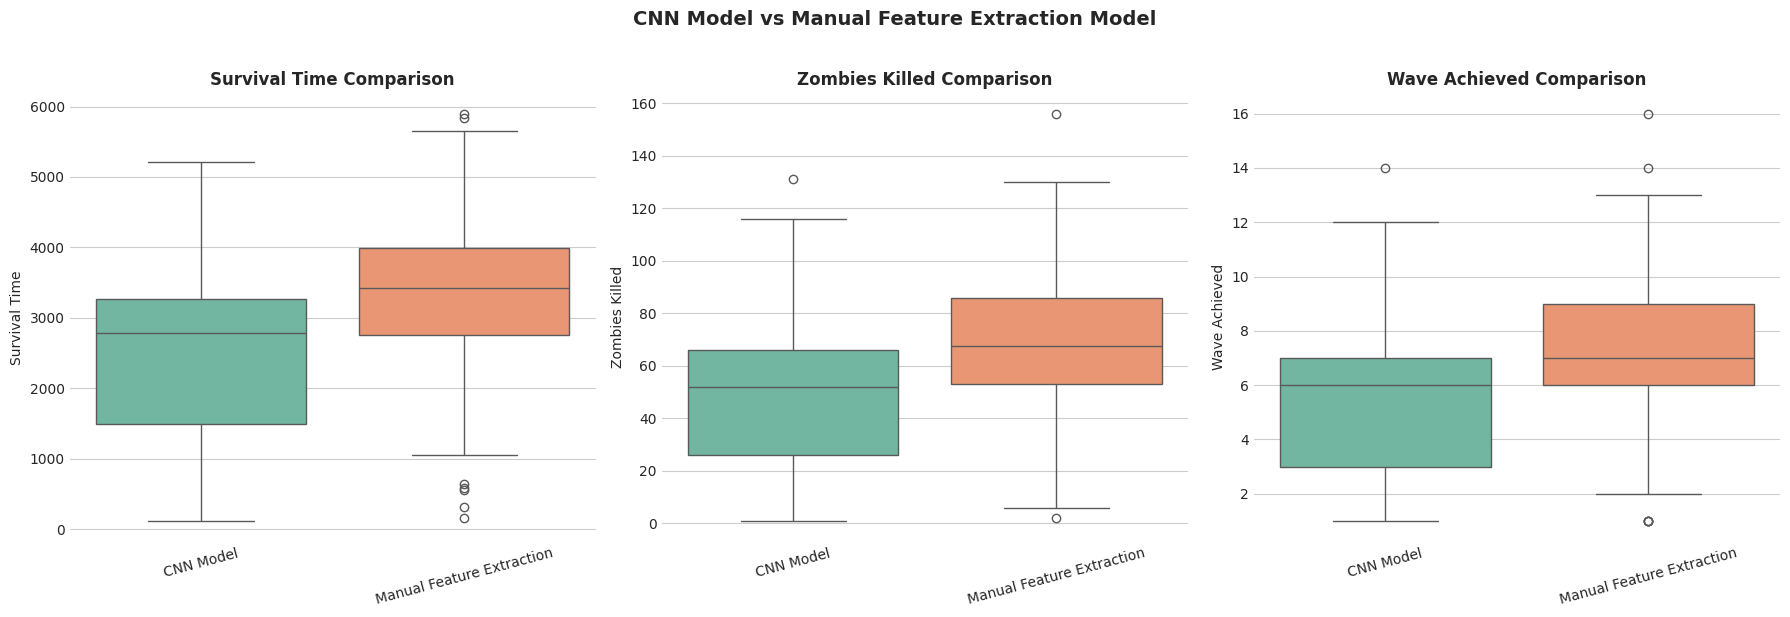

In [21]:
# Visual Comparison - Box Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, metric in enumerate(metrics):
    sns.boxplot(data=comparison_df, x='model_type', y=metric, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{metric.replace("_", " ").title()} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(metric.replace("_", " ").title())
    axes[idx].tick_params(axis='x', rotation=15)

plt.suptitle('CNN Model vs Manual Feature Extraction Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Statistical Tests: CNN vs Manual Feature Extraction

Since we're comparing two groups, we'll use:
1. **Shapiro-Wilk Test** - Check normality for each group
2. **Mann-Whitney U Test** - Non-parametric test for comparing two independent groups (if not normal)
3. **Effect Size (Cohen's d)** - Measure the practical significance of the difference

In [23]:
# Normality Test for both groups
print("="*80)
print("NORMALITY TEST (Shapiro-Wilk)")
print("="*80)

normality_results = []
for model_type in ['CNN Model', 'Manual Feature Extraction']:
    model_data = comparison_df[comparison_df['model_type'] == model_type]
    for metric in metrics:
        data = model_data[metric].values
        stat, p_value = shapiro(data)
        is_normal = p_value > 0.05
        normality_results.append({
            'Model Type': model_type,
            'Metric': metric,
            'Statistic': stat,
            'p_value': p_value,
            'Normal?': 'Yes' if is_normal else 'No'
        })

normality_comparison_df = pd.DataFrame(normality_results)
normality_comparison_df

NORMALITY TEST (Shapiro-Wilk)


,Model Type,Metric,Statistic,p_value,Normal?
0,CNN Model,survival_time,0.965223,0.009645,No
1,CNN Model,zombies_killed,0.972966,0.037443,No
2,CNN Model,wave_achieved,0.951491,0.001041,No
3,Manual Feature Extraction,survival_time,0.963554,0.007265,No
4,Manual Feature Extraction,zombies_killed,0.978316,0.098179,Yes
5,Manual Feature Extraction,wave_achieved,0.962312,0.005897,No


In [24]:
# Mann-Whitney U Test (Non-parametric comparison)
print("="*80)
print("MANN-WHITNEY U TEST (Non-Parametric)")
print("="*80)
print("H0: The distributions of both groups are equal")
print("H1: The distributions of both groups are different")
print("If p < 0.05: Reject H0 → Significant difference exists between models")
print("="*80)

cnn_data = comparison_df[comparison_df['model_type'] == 'CNN Model']
manual_data = comparison_df[comparison_df['model_type'] == 'Manual Feature Extraction']

mann_whitney_results = []
for metric in metrics:
    cnn_values = cnn_data[metric].values
    manual_values = manual_data[metric].values
    
    stat, p_value = mannwhitneyu(cnn_values, manual_values, alternative='two-sided')
    
    # Calculate effect size (rank-biserial correlation)
    n1, n2 = len(cnn_values), len(manual_values)
    effect_size = 1 - (2 * stat) / (n1 * n2)
    
    mann_whitney_results.append({
        'Metric': metric,
        'U Statistic': stat,
        'p_value': p_value,
        'Significant?': 'Yes' if p_value < 0.05 else 'No',
        'Effect Size (r)': abs(effect_size),
        'Effect Interpretation': 'Large' if abs(effect_size) > 0.5 else ('Medium' if abs(effect_size) > 0.3 else 'Small')
    })

mann_whitney_df = pd.DataFrame(mann_whitney_results)
mann_whitney_df

MANN-WHITNEY U TEST (Non-Parametric)
H0: The distributions of both groups are equal
H1: The distributions of both groups are different
If p < 0.05: Reject H0 → Significant difference exists between models


,Metric,U Statistic,p_value,Significant?,Effect Size (r),Effect Interpretation
0,survival_time,3099.5,0.000003,Yes,0.3801,Medium
1,zombies_killed,3084.5,0.000003,Yes,0.3831,Medium
2,wave_achieved,3074.5,0.000002,Yes,0.3851,Medium


best_model_marouane is the best model overall